<font color="black"><font size="7"><br>
     Projet 5 - Clustering 
</font>
    

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
import category_encoders as ce


%matplotlib inline

# Importing data

In [9]:
full_df = pd.read_pickle('data/full_df')

In [10]:
quarters_df = np.load('data/quarters_df.npy',allow_pickle=True)

## Quantile calculation

In [74]:
def create_rfm_scores(df_final):
    quantile = df_final.quantile(q=[0.2,0.4,0.6,0.8])
    #Frequency score
    df_final['frequency_score'] = [2 if 0<f<=1
                              else 1 for f in df_final['frequency']]
    #Recency score
    df_final['recency_score'] = [1 if 0 < f <= quantile.iloc[0]['recency']
                             else 2 if quantile.iloc[0]['recency'] < f <= quantile.iloc[1]['recency']
                             else 3 if quantile.iloc[1]['recency'] < f <= quantile.iloc[2]['recency']
                             else 4 if quantile.iloc[2]['recency'] < f <= quantile.iloc[3]['recency']
                             else 5 for f in df_final['recency']]
    #Monetary score
    df_final['monetary_score'] = [5 if 0 < f <= quantile.iloc[0]['monetary_log']
                             else 4 if quantile.iloc[0]['monetary_log'] < f <= quantile.iloc[1]['monetary_log']
                             else 3 if quantile.iloc[1]['monetary_log'] < f <= quantile.iloc[2]['monetary_log']
                             else 2 if quantile.iloc[2]['monetary_log'] < f <= quantile.iloc[3]['monetary_log']
                             else 1 for f in df_final['monetary_log']]
    
    #Final score
    df_final['RFM_score'] = df_final['frequency_score'] + \
    df_final['recency_score'] + df_final['monetary_score']
    
    return df_final

In [75]:
full_df = create_rfm_scores(full_df)

In [76]:
for i in range(len(quarters_df)):
    quarters_df[i]=create_rfm_scores(quarters_df[i])  

### EDA

#### ANOVA

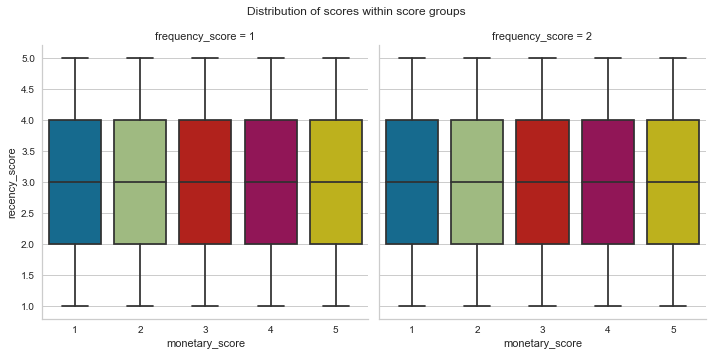

In [78]:

sns.catplot(x='monetary_score',
            y='recency_score',
            col='frequency_score',
            kind='box',
           data=full_df)
plt.suptitle('Distribution of scores within score groups')
plt.tight_layout()
plt.show()

### Manual Clustering

In [79]:
rfm_quantile = full_df['RFM_score'].quantile([1/3,2/3])

In [80]:
rfm_quantile.iloc[0]

7.0

In [81]:
full_df['RFM_manual_cluster'] = [ 1 if 0 < f < rfm_quantile.iloc[0]
                                 else 2 if rfm_quantile.iloc[0] <= f <= rfm_quantile.iloc[1]
                                 else 3 for f in full_df['RFM_score'] ]

In [82]:
full_df['RFM_manual_cluster'].unique()

array([2, 1, 3], dtype=int64)

#### Cluster analysis

In [83]:
silh_scores = {}

In [84]:
silh_scores['Manual RFM'] = silhouette_score(full_df[['frequency_score',
                                                      'recency_score',
                                                      'monetary_score']]
                                             ,full_df['RFM_manual_cluster'])

In [85]:
silhouettes_rfm = silhouette_samples(full_df[['frequency_score',
                                               'recency_score',
                                               'monetary_score']],
                                     full_df['RFM_manual_cluster'])

In [86]:
full_df['silhouette_rfm_coef'] = silhouettes_rfm

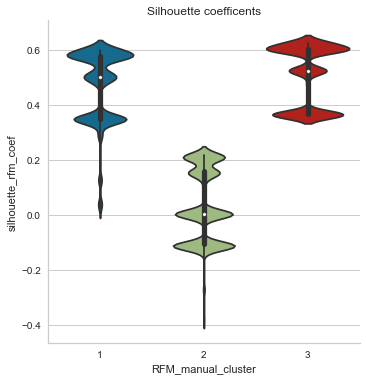

In [87]:
sns.catplot(x='RFM_manual_cluster',y='silhouette_rfm_coef',data=full_df,kind='violin')
plt.title('Silhouette coefficents')
plt.show()

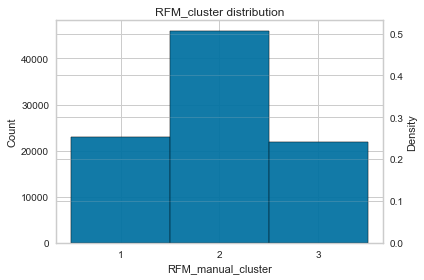

In [88]:
fig, ax = plt.subplots()

sns.histplot(full_df['RFM_manual_cluster'],discrete=True, ax=ax)

ax2 = ax.twinx()
sns.histplot(full_df['RFM_manual_cluster'],stat='density',discrete=True, ax=ax2)

plt.title('RFM_cluster distribution')
plt.xlabel('RFM_cluster')
plt.xticks([1,2,3],['1','2','3'])


plt.tight_layout()
plt.show()


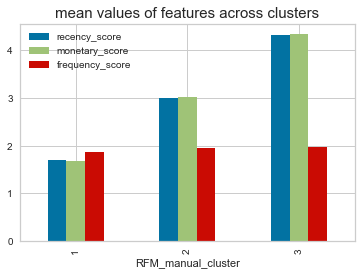

In [89]:
full_df.groupby('RFM_manual_cluster').mean()[['recency_score','monetary_score','frequency_score']].plot(kind='bar')
plt.title('mean values of features across clusters',fontsize=15)
plt.show()

#### Cluster profile

In [90]:
A = full_df.groupby('RFM_manual_cluster').mean()[['recency_score','monetary_score','frequency_score']]

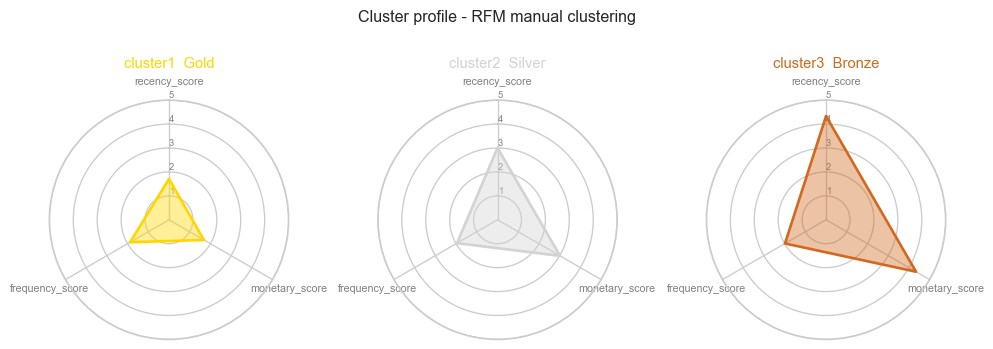

In [91]:
from math import pi
# ------- PART 1: Define a function that do a plot for one line of the dataset!
 
def make_spider( data, row, title, color):
 
    # number of variable
    categories=list(data)
    N = len(categories)
 
    # What will be the angle of each axis in the plot? (we divide the plot / number of variable)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
 
    # Initialise the spider plot
    ax = plt.subplot(3,3,row, polar=True, )
 
    # If you want the first axis to be on top:
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
 
    # Draw one axe per variable + add labels labels yet
    plt.xticks(angles[:-1], categories, color='grey', size=8)
 
    # Draw ylabels
    ax.set_rlabel_position(0)
    plt.yticks([1,2,3,4,5], ["1","2","3","4","5"], color="grey", size=7)
    plt.ylim(0,5)
 
    # Ind1
    values=data.loc[row].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, linestyle='solid')
    ax.fill(angles, values, color=color, alpha=0.4)
 
    # Add a title
    plt.title(title, size=11, color=color, y=1.1)
    return None
 
# ------- PART 2: Apply to all individuals
# initialize the figure
my_dpi=96
plt.figure(figsize=(1000/my_dpi, 1000/my_dpi), dpi=my_dpi)
 
# Create a color palette:
#my_palette = plt.cm.get_cmap("Set2", len(A.index))
my_palette = ['gold','lightgrey','chocolate']
labels=['Gold','Silver','Bronze']

# Loop to plot
for row in range(0, len(A.index)):
    make_spider( data=A, row=row+1, title='cluster'+str(row+1)+'  '+ str(labels[row]), color=my_palette[row])

plt.suptitle('Cluster profile - RFM manual clustering')
plt.tight_layout()

In [92]:
fig, axes = plt.subplots(1,3)
fig.set_size_inches(12, 4)
i=0
for col in full_df['recency_score','monetary_score','frequency_score']].columns:
    ax=axes[i%3]
    sns.boxplot(x='RFM_manual_cluster',
               y=col,
               data=df_final,
               #palette='rainbow',
               palette=my_palette,
               showfliers=False,
               ax=ax
               )
    ax.set_title(f'{col}')
    ax.set_xlabel('')
    ax.set_xticklabels(['Gold','Silver','Bronze'])
    ax.set_ylabel('value')
    i+=1
fig.suptitle('Score distribution on clusters',fontsize=15)
plt.tight_layout()
plt.show()

SyntaxError: unmatched ']' (<ipython-input-92-2a6eedbb4137>, line 4)

## K-means

### Standardisation

In [119]:
scaler = StandardScaler()

### Comparing with manual clustering

In [120]:
X_scaled = scaler.fit_transform(df_final[['recency_score','monetary_score','frequency_score']])

In [121]:
model = KMeans(n_clusters=3)

In [122]:
model.fit(X_scaled)

KMeans(n_clusters=3)

In [123]:
df_final['class_predicted_k_3'] = model.predict(X_scaled)+1

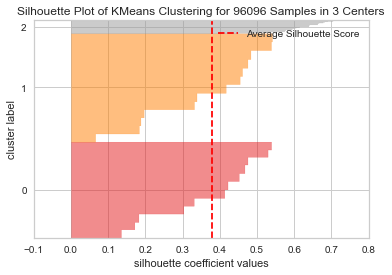

<AxesSubplot:title={'center':'Silhouette Plot of KMeans Clustering for 96096 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [124]:
visualizer = SilhouetteVisualizer(model)

visualizer.fit(X_scaled)    # Fit the dataa to the visualizer
visualizer.poof()    # Draw/show/poof the data

In [125]:
df_final['silhouette_k_3']=silhouette_samples(df_final[['frequency_score','recency_score','monetary_score']],df_final['class_predicted_k_3'])

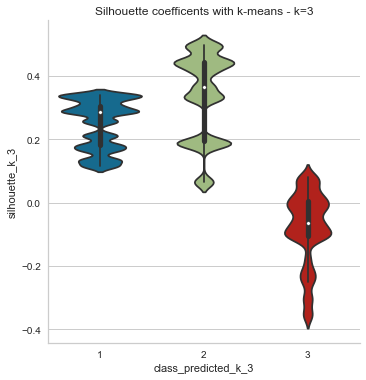

In [126]:
sns.catplot(x='class_predicted_k_3',y='silhouette_k_3',data=df_final,kind='violin')
plt.title('Silhouette coefficents with k-means - k=3')
plt.show()

In [127]:
silh_scores['kmeans k=3'] = silhouette_score(df_final[['frequency_score','recency_score','monetary_score']],df_final['class_predicted_k_3'])

In [128]:
silh_scores

{'Manual RFM': 0.26068919087686676, 'kmeans k=3': 0.27305285542489366}

In [129]:
B = df_final.groupby('class_predicted_k_3').mean()[['recency_score','monetary_score','frequency_score']]

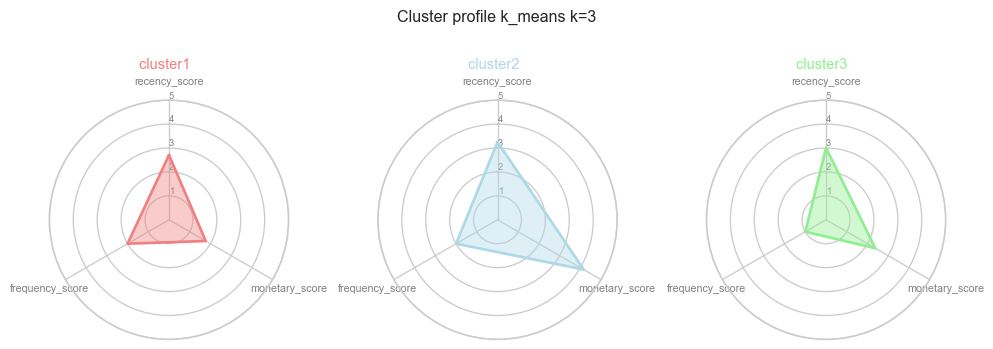

In [130]:
# ------- PART 2: Apply to all individuals
# initialize the figure
my_dpi=96
plt.figure(figsize=(1000/my_dpi, 1000/my_dpi), dpi=my_dpi)
 
# Create a color palette:
#my_palette = plt.cm.get_cmap("Set2", len(A.index))
my_palette = ['lightcoral','lightblue','lightgreen']
labels=['','','']

# Loop to plot
for row in range(0, len(B.index)):
    make_spider(data=B, row=row+1, title='cluster'+str(row+1)+'  '+ str(labels[row]), color=my_palette[row])

plt.suptitle('Cluster profile k_means k=3')
plt.tight_layout()

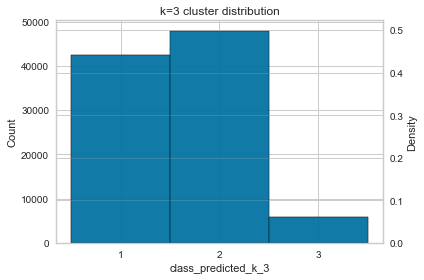

In [131]:
fig, ax = plt.subplots()

sns.histplot(df_final['class_predicted_k_3'],discrete=True, ax=ax)

ax2 = ax.twinx()
sns.histplot(df_final['class_predicted_k_3'],stat='density',discrete=True, ax=ax2)

plt.title('k=3 cluster distribution')
plt.xlabel('Cluster')
plt.xticks([1,2,3],['1','2','3'])


plt.tight_layout()
plt.show()

### Optimising number of clusters

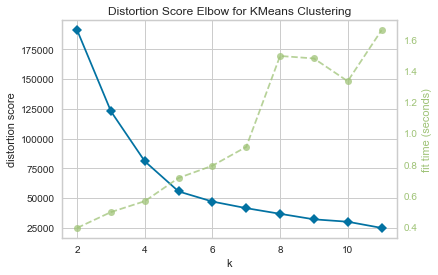

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [58]:
k_model = KMeans()
# Instantiate the clustering model and visualizer

visualizer = KElbowVisualizer(k_model, k=(2,12), locate_elbow=False)

visualizer.fit(X_scaled)    # Fit the data to the visualizer
visualizer.poof()    # Draw/show/poof the data

In [59]:
model = KMeans(n_clusters=5)

In [60]:
model.fit(X_scaled)

KMeans(n_clusters=5)

In [61]:
df_final['class_predicted_k_5'] = model.predict(X_scaled)+1

In [62]:
df_final['silhouette_k_5'] = silhouette_samples(
    df_final[['frequency_score', 'recency_score', 'monetary_score']], df_final['class_predicted_k_5'])

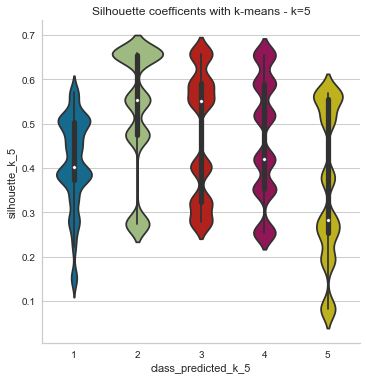

In [63]:
sns.catplot(x='class_predicted_k_5',y='silhouette_k_5',data=df_final,kind='violin')
plt.title('Silhouette coefficents with k-means - k=5')
plt.show()

In [64]:
silh_scores['kmeans k=5'] = silhouette_score(df_final[['frequency_score','recency_score','monetary_score']],df_final['class_predicted_k_5'])

In [65]:
silh_scores

{'Manual RFM': 0.23398911463988234,
 'kmeans k=3': 0.37427701012878173,
 'kmeans k=5': 0.44013533871616733}

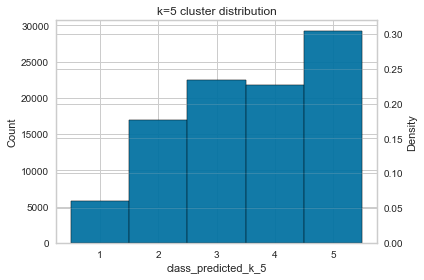

In [79]:
fig, ax = plt.subplots()

sns.histplot(df_final['class_predicted_k_5'],discrete=True, ax=ax)

ax2 = ax.twinx()
sns.histplot(df_final['class_predicted_k_5'],stat='density',discrete=True, ax=ax2)

plt.title('k=5 cluster distribution')
plt.xlabel('Cluster')
plt.xticks([1,2,3,4,5],['1','2','3','4','5'])


plt.tight_layout()
plt.show()

In [66]:
C = df_final.groupby('class_predicted_k_5').mean()[['recency_score','monetary_score','frequency_score']]

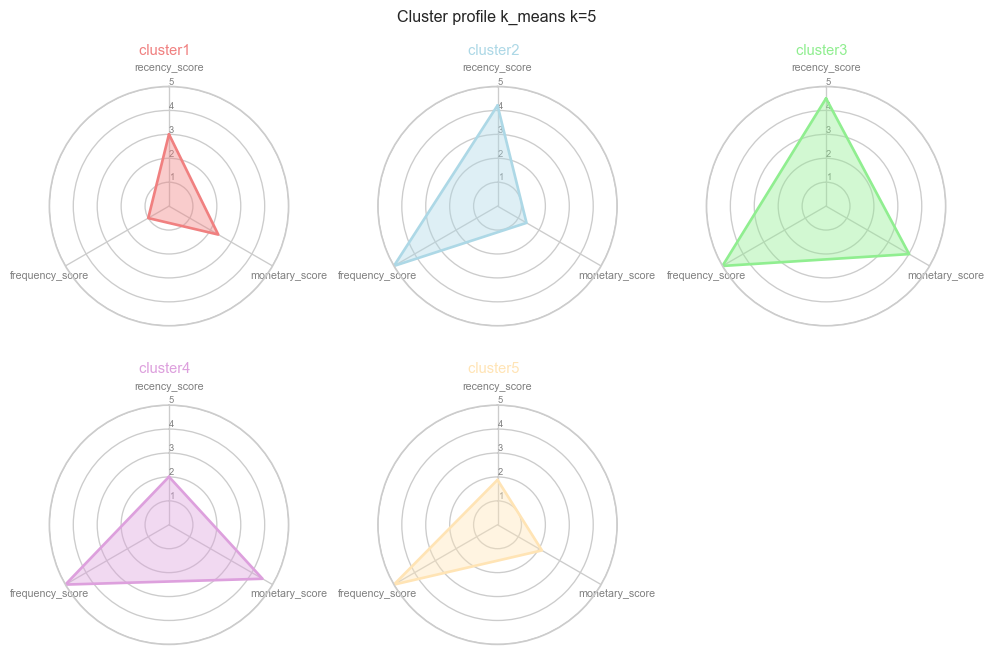

In [67]:
# ------- PART 2: Apply to all individuals
# initialize the figure
my_dpi=96
plt.figure(figsize=(1000/my_dpi, 1000/my_dpi), dpi=my_dpi)
 
# Create a color palette:
#my_palette = plt.cm.get_cmap("Set2", len(A.index))
my_palette = ['lightcoral','lightblue','lightgreen','plum','moccasin']
labels=['','','','','']

# Loop to plot
for row in range(0, len(C.index)):
    make_spider(data=C, row=row+1, title='cluster'+str(row+1)+'  '+ str(labels[row]), color=my_palette[row])

plt.suptitle('Cluster profile k_means k=5')
plt.tight_layout()

### Using variables selected from pca

In [68]:
df_final.columns

Index(['customer_unique_id', 'frequency', 'recency', 'monetary',
       'monetary_log', 'review_score_mean', 'review_score_count',
       'delivery_difference_time', 'payment_installments',
       'purchase_weekday_encode', 'frequency_score', 'recency_score',
       'monetary_score', 'RFM_score', 'RFM_manual_cluster',
       'silhouette_rfm_coef', 'class_predicted_k_3', 'silhouette_k_3',
       'class_predicted_k_5', 'silhouette_k_5'],
      dtype='object')

In [80]:
X_scaled = scaler.fit_transform(df_final[['monetary_score',
                                          'frequency_score',
                                          'payment_installments',
                                          'review_score_count']])

In [81]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer()

In [82]:
X_scaled = imputer.fit_transform(X_scaled)

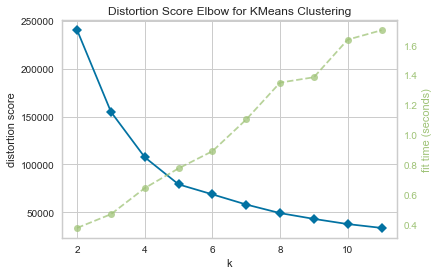

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [83]:
k_model = KMeans()
# Instantiate the clustering model and visualizer

visualizer = KElbowVisualizer(k_model, k=(2,12), locate_elbow=False)

visualizer.fit(X_scaled)    # Fit the data to the visualizer
visualizer.poof()    # Draw/show/poof the data

In [84]:
model = KMeans(n_clusters=5)

In [85]:
model.fit(X_scaled)

KMeans(n_clusters=5)

In [86]:
df_final['class_predicted_k_5_pca'] = model.predict(X_scaled)+1

In [89]:
silh_scores['kmeans k=5 pca'] = silhouette_score(X_scaled,
                                                 df_final['class_predicted_k_5_pca'])

In [90]:
silh_scores

{'Manual RFM': 0.23398911463988234,
 'kmeans k=3': 0.37427701012878173,
 'kmeans k=5': 0.44013533871616733,
 'kmeans k=5 weekday': 0.18019276282252422,
 'kmeans k=5 pca': 0.5197077720845056}

In [91]:
D = df_final.groupby('class_predicted_k_5_pca').mean()[['monetary_score',
                                          'frequency_score',
                                          'payment_installments',
                                          'review_score_count']]

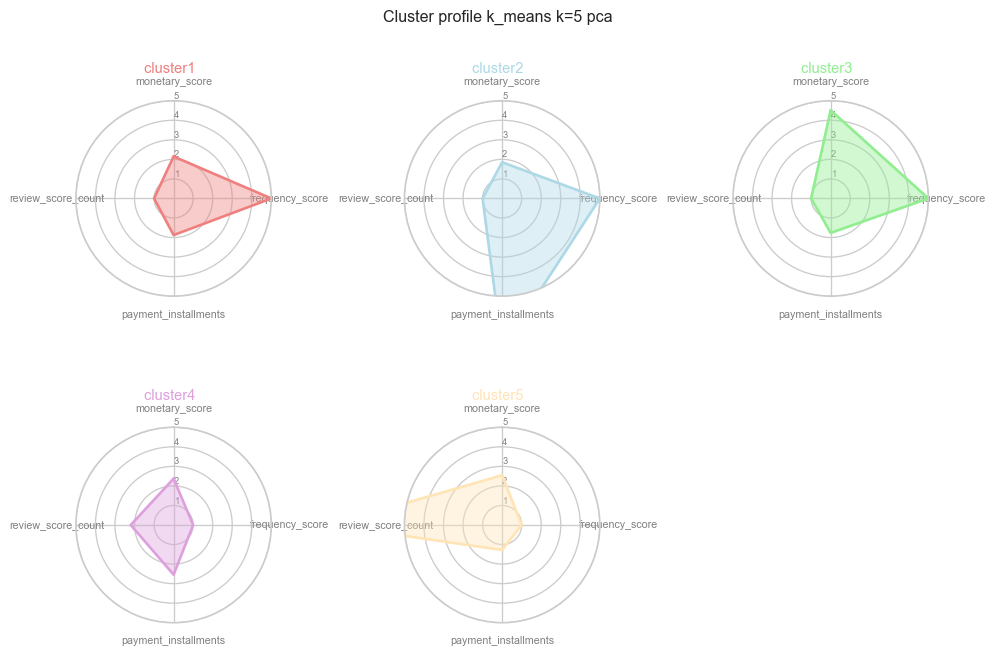

In [92]:
# ------- PART 2: Apply to all individuals
# initialize the figure
my_dpi=96
plt.figure(figsize=(1000/my_dpi, 1000/my_dpi), dpi=my_dpi)
 
# Create a color palette:
#my_palette = plt.cm.get_cmap("Set2", len(A.index))
my_palette = ['lightcoral','lightblue','lightgreen','plum','moccasin']
labels=['','','','','']

# Loop to plot
for row in range(0, len(C.index)):
    make_spider(data=D, row=row+1, title='cluster'+str(row+1)+'  '+ str(labels[row]), color=my_palette[row])

plt.suptitle('Cluster profile k_means k=5 pca')
plt.tight_layout()